# Pertemuan 7 - Pengantar Machine Learning: Regresi Linear

**Nama:** Nabil Fakhrezy  
**NIM:** 240401010286  
**Kelas:** IF401  
**Program Studi:** PJJ Informatika

## Materi
Regresi Linear untuk prediksi gaji menggunakan dataset sintetis.


## 1. Generate Dataset


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


,pengalaman,edu,gaji
count,300.00,300.00,300.00
mean,9.90,0.89,27.40
std,5.89,0.83,13.41
min,0.10,0.00,1.67
25%,4.78,0.00,16.24
50%,10.23,1.00,27.97
75%,15.14,2.00,38.89
max,19.80,2.00,54.22


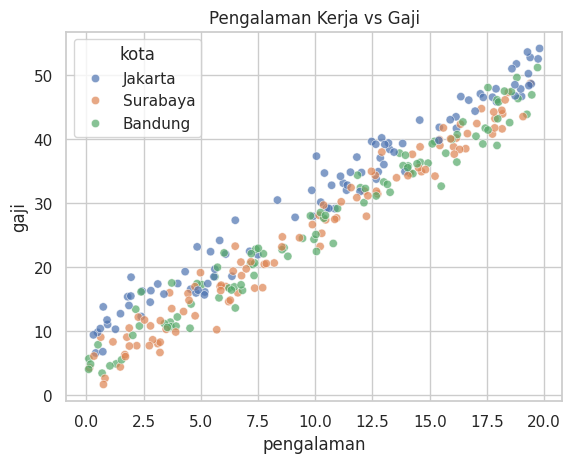

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)

n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)
kota = np.random.choice(["Jakarta", "Surabaya", "Bandung"], n)

gaji = 3.0 + 2.2*pengalaman + 1.5*edu + np.where(kota=="Jakarta", 4.0, 0) + np.random.normal(0, 2, n)
df = pd.DataFrame({"pengalaman": pengalaman, "edu": edu, "kota": kota, "gaji": gaji})

display(df.head())
display(df.describe().round(2))
sns.scatterplot(data=df, x="pengalaman", y="gaji", hue="kota", alpha=0.7)
plt.title("Pengalaman Kerja vs Gaji")
plt.show()


## 2. Preprocessing dan Training Model


In [2]:
df_encoded = pd.get_dummies(df, columns=["kota"], drop_first=True, dtype=int)

X = df_encoded.drop("gaji", axis=1)
y = df_encoded["gaji"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = ["pengalaman", "edu"]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

model = LinearRegression()
model.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({"Fitur": X_train_scaled.columns, "Koefisien": model.coef_})
display(coef_df.round(3))


,Fitur,Koefisien
0,pengalaman,13.042
1,edu,1.188
2,kota_Jakarta,3.852
3,kota_Surabaya,-0.611


## 3. Evaluasi Model


MAE  : 1.649
RMSE : 2.123
R²   : 0.974


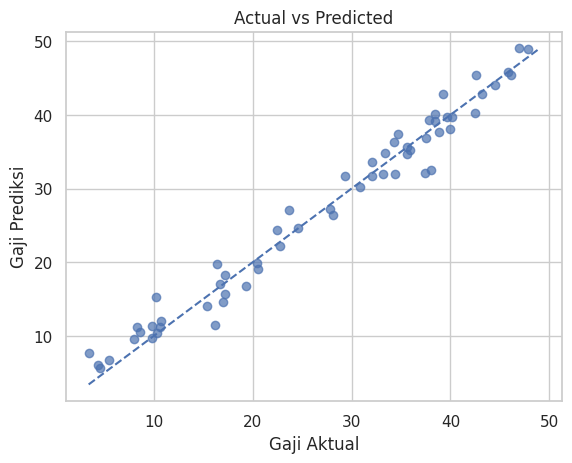

In [3]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

plt.scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.title("Actual vs Predicted")
plt.xlabel("Gaji Aktual")
plt.ylabel("Gaji Prediksi")
plt.show()


## Kesimpulan

Saya mempelajari regresi linear untuk memprediksi nilai kontinu. Temuan utama adalah pengalaman kerja berhubungan positif dengan gaji. Keterbatasannya, dataset masih sintetis.
